<a href="https://colab.research.google.com/github/mdanmek/nida-dads-notes/blob/main/dads5001-data-tools/project/eda/04_construction_review_indicators_2569.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# การตรวจรูปแบบโครงการจ้างก่อสร้าง ปีงบประมาณ 2569

ข้อมูล e-GP ปีงบประมาณ 2569 สะสมถึงวันที่ 30 กรกฎาคม 2569 ไม่ใช่ข้อมูลเต็มปี

ผลลัพธ์ใช้สำหรับจัดลำดับการตรวจเอกสาร ไม่ใช่หลักฐานว่ามีการทุจริตหรือแบ่งซื้อแบ่งจ้าง

In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

!wget -q https://github.com/Phonbopit/sarabun-webfont/raw/master/fonts/thsarabunnew-webfont.ttf
fm.fontManager.addfont('thsarabunnew-webfont.ttf')

sns.set_theme(style='whitegrid', font='TH Sarabun New')

plt.rcParams.update({
    'axes.titlesize': 18,
    'axes.titleweight': 'semibold',
    'axes.labelsize': 13,
    'xtick.labelsize': 11,
    'ytick.labelsize': 12,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.unicode_minus': False
})

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)
pd.set_option('display.float_format', lambda value: f'{value:,.2f}')

BLUE = '#5B7FA3'
ORANGE = '#D9822B'
GRAY = '#B8C2CC'
TEXT = '#344054'
MUTED = '#667085'
GRID = '#E4E7EC'

In [3]:
processed_dir = Path('/content/drive/MyDrive/learning/dads/dads5001/project_1_dads5001/dataset/procurement/egp-contract/processed')

figure_dir = processed_dir.parents[3] / 'figure'
figure_dir.mkdir(parents=True, exist_ok=True)

project_path = processed_dir / 'construction_projects_2569.csv'
contract_path = processed_dir / 'construction_contracts_2569.csv'

project_data = pd.read_csv(project_path, low_memory=False)
contract_data = pd.read_csv(contract_path, low_memory=False)

print(f'Project rows: {len(project_data):,}')
print(f'Contract–supplier rows: {len(contract_data):,}')
print(f'Figure directory: {figure_dir}')

Project rows: 178,978
Contract–supplier rows: 179,716
Figure directory: /content/drive/MyDrive/learning/dads/dads5001/project_1_dads5001/figure


In [4]:
project_id_column = 'รหัสโครงการ'
project_name_column = 'ชื่อโครงการจัดซื้อจัดจ้าง'
agency_column = 'ชื่อหน่วยงาน'
subagency_column = 'ชื่อหน่วยงานย่อย'
province_column = 'จังหวัด'
method_column = 'ชื่อวิธีการจัดซื้อจัดจ้าง'
budget_column = 'วงเงินงบประมาณ (บาท)'
reference_price_column = 'ราคากลาง (บาท)'
awarded_price_column = 'ราคาที่ตกลงซื้อ / จ้าง ซึ่งรวมทุกสัญญาในโครงการ (บาท)'
transaction_date_column = 'วันที่เกิดรายการ'
contract_value_column = 'วงเงินงบประมาณในสัญญา (บาท)'
supplier_id_column = 'เลขประจำตัวนิติบุคคล 13 หลัก'
supplier_name_column = 'ชื่อผู้ชนะการเสนอราคา'

specific_method_value = 'เฉพาะเจาะจง'
legal_budget_ceiling = 500_000

project_data['in_study_scope'] = (project_data[method_column].eq(specific_method_value) & project_data[budget_column].le(legal_budget_ceiling))

study_project_data = project_data.loc[project_data['in_study_scope']].copy()

assert len(project_data) == 178_978
assert len(study_project_data) == 136_070

study_project_ids = set(study_project_data[project_id_column])

study_summary = pd.Series({
    'โครงการก่อสร้างทั้งหมด': len(project_data),
    'โครงการในกลุ่มศึกษา': len(study_project_data),
    'สัดส่วนโครงการทั้งหมด (%)': (
        len(study_project_data) / len(project_data) * 100
    )
}, name='value')

display(study_summary.to_frame())

,value
โครงการก่อสร้างทั้งหมด,"178,978.00"
โครงการในกลุ่มศึกษา,"136,070.00"
สัดส่วนโครงการทั้งหมด (%),76.03


## 1. เตรียมข้อมูลผู้รับจ้าง

In [5]:
contract_data['is_joint_venture_member'] = (
    contract_data[supplier_name_column]
    .astype('string')
    .str.contains('สัญญากิจการค้าร่วม', na=False)
)

supplier_entity_data = contract_data.loc[
    ~contract_data['is_joint_venture_member']
    & contract_data[supplier_id_column].notna()
].copy()

project_supplier_data = (
    supplier_entity_data
    .groupby(
        [project_id_column, supplier_id_column],
        dropna=False
    )
    .agg(
        supplier_name=(supplier_name_column, 'first'),
        supplier_awarded_value=(contract_value_column, 'sum')
    )
    .reset_index()
    .merge(
        project_data[
            [
                project_id_column,
                project_name_column,
                agency_column,
                subagency_column,
                province_column,
                method_column,
                budget_column,
                awarded_price_column,
                transaction_date_column,
                'in_study_scope'
            ]
        ],
        on=project_id_column,
        how='left',
        validate='many_to_one'
    )
)

print(f'แถวสมาชิก Joint Venture ที่ไม่นับซ้ำ: {contract_data["is_joint_venture_member"].sum():,}')
print(f'คู่โครงการ–ผู้รับจ้าง: {len(project_supplier_data):,}')
print(f'โครงการที่มีรหัสผู้รับจ้าง: {project_supplier_data[project_id_column].nunique():,}')

แถวสมาชิก Joint Venture ที่ไม่นับซ้ำ: 710
คู่โครงการ–ผู้รับจ้าง: 178,786
โครงการที่มีรหัสผู้รับจ้าง: 178,620


In [6]:
supplier_value_by_project = (
    project_supplier_data
    .groupby(project_id_column)['supplier_awarded_value']
    .sum()
    .rename('supplier_value_sum')
)

supplier_reconciliation = (
    project_data[
        [project_id_column, awarded_price_column]
    ]
    .merge(
        supplier_value_by_project,
        on=project_id_column,
        how='left'
    )
)

supplier_reconciliation['is_matched'] = np.isclose(
    supplier_reconciliation['supplier_value_sum'],
    supplier_reconciliation[awarded_price_column],
    rtol=0,
    atol=1,
    equal_nan=False
)

reconciliation_summary = pd.Series({
    'โครงการที่ตรวจ': len(supplier_reconciliation),
    'โครงการที่มูลค่าตรงกัน': supplier_reconciliation['is_matched'].sum(),
    'โครงการที่มูลค่าไม่ตรงกัน': (~supplier_reconciliation['is_matched']).sum(),
    'สัดส่วนที่ตรงกัน (%)': supplier_reconciliation['is_matched'].mean() * 100
}, name='value')

display(reconciliation_summary.to_frame())

,value
โครงการที่ตรวจ,"178,978.00"
โครงการที่มูลค่าตรงกัน,"178,616.00"
โครงการที่มูลค่าไม่ตรงกัน,362.00
สัดส่วนที่ตรงกัน (%),99.80


### ผลการเตรียมข้อมูล

แถวสมาชิก Joint Venture ไม่นำมารวมซ้ำในการคำนวณมูลค่าของผู้รับจ้าง

## 2. Pattern 1 — โครงการใกล้เพดานที่เกิดซ้ำ

เงื่อนไขหลัก:

- วิธีเฉพาะเจาะจง
- วงเงิน 490,000–500,000 บาท
- หน่วยงานย่อย ผู้รับจ้าง และวันที่เกิดรายการเดียวกัน
- อย่างน้อย 3 โครงการ

In [7]:
near_ceiling_windows = [
    (450_000, '450,000–500,000'),
    (480_000, '480,000–500,000'),
    (490_000, '490,000–500,000'),
    (495_000, '495,000–500,000')
]

window_records = []

for lower_bound, label in near_ceiling_windows:
    valid_cluster_rows = (
        project_supplier_data[subagency_column].notna()
        & project_supplier_data[supplier_id_column].notna()
        & project_supplier_data[transaction_date_column].notna()
        & project_supplier_data[transaction_date_column].ne('-')
    )

    window_data = project_supplier_data.loc[
        project_supplier_data['in_study_scope']
        & valid_cluster_rows
        & project_supplier_data[budget_column].between(
            lower_bound,
            legal_budget_ceiling,
            inclusive='both'
        )
    ]

    window_clusters = (
        window_data
        .groupby(
            [
                subagency_column,
                supplier_id_column,
                transaction_date_column
            ],
            dropna=False
        )[project_id_column]
        .nunique()
    )

    selected_clusters = window_clusters.loc[
        window_clusters.ge(3)
    ]

    window_records.append({
        'ช่วงวงเงิน': label,
        'โครงการในช่วง': window_data[project_id_column].nunique(),
        'กลุ่มอย่างน้อย 3 โครงการ': len(selected_clusters),
        'โครงการในกลุ่ม': selected_clusters.sum()
    })

near_ceiling_sensitivity = pd.DataFrame(window_records)
display(near_ceiling_sensitivity)

,ช่วงวงเงิน,โครงการในช่วง,กลุ่มอย่างน้อย 3 โครงการ,โครงการในกลุ่ม
0,"450,000–500,000",37188,1717,7376
1,"480,000–500,000",30687,1458,6409
2,"490,000–500,000",26144,1244,5613
3,"495,000–500,000",20734,919,4052


In [8]:
valid_cluster_rows = (
    project_supplier_data[subagency_column].notna()
    & project_supplier_data[supplier_id_column].notna()
    & project_supplier_data[transaction_date_column].notna()
    & project_supplier_data[transaction_date_column].ne('-')
)

near_ceiling_data = project_supplier_data.loc[
    project_supplier_data['in_study_scope']
    & valid_cluster_rows
    & project_supplier_data[budget_column].between(
        490_000,
        legal_budget_ceiling,
        inclusive='both'
    )
].copy()

cluster_columns = [
    subagency_column,
    supplier_id_column,
    transaction_date_column
]

near_ceiling_clusters = (
    near_ceiling_data
    .groupby(cluster_columns, dropna=False)
    .agg(
        supplier_name=('supplier_name', 'first'),
        project_count=(project_id_column, 'nunique'),
        total_budget=(budget_column, 'sum')
    )
    .reset_index()
)

repeated_clusters = (
    near_ceiling_clusters.loc[
        near_ceiling_clusters['project_count'].ge(3)
    ]
    .sort_values(
        ['project_count', 'total_budget'],
        ascending=False
    )
    .reset_index(drop=True)
)

pattern1_project_ids = set(
    near_ceiling_data
    .merge(
        repeated_clusters[cluster_columns],
        on=cluster_columns,
        how='inner',
        validate='many_to_many'
    )[project_id_column]
)

project_data['flag_pattern_1'] = (
    project_data[project_id_column].isin(pattern1_project_ids)
)

pattern1_summary = pd.Series({
    'กลุ่มที่ผ่านเกณฑ์': len(repeated_clusters),
    'โครงการที่เกี่ยวข้อง': project_data['flag_pattern_1'].sum(),
    'สัดส่วนกลุ่มศึกษา (%)': (
        project_data['flag_pattern_1'].sum()
        / len(study_project_data)
        * 100
    )
}, name='value')

display(pattern1_summary.to_frame())
display(repeated_clusters.head(15))

,value
กลุ่มที่ผ่านเกณฑ์,"1,244.00"
โครงการที่เกี่ยวข้อง,"5,613.00"
สัดส่วนกลุ่มศึกษา (%),4.13


,ชื่อหน่วยงานย่อย,เลขประจำตัวนิติบุคคล 13 หลัก,วันที่เกิดรายการ,supplier_name,project_count,total_budget
0,สำนักงานทรัพยากรธรรมชาติและสิ่งแวดล้อมจังหวัด มุกดาหาร,0115556009669,29 ธ.ค. 68,บริษัท บ้านบุ่ง วิศวกรรม จำกัด,65,"32,370,000.00"
1,สำนักงานทรัพยากรธรรมชาติและสิ่งแวดล้อมจังหวัด ร้อยเอ็ด,0503566000201,28 ต.ค. 68,ห้างหุ้นส่วนจำกัด เด็พซัน,40,"19,960,000.00"
2,องค์การบริหารส่วนจังหวัดนครพนม,0485564000851,22 เม.ย. 69,บริษัท พนมนาคราช (2021) จำกัด,35,"17,150,000.00"
3,องค์การบริหารส่วนจังหวัดนครพนม,0485564000851,17 ต.ค. 68,บริษัท พนมนาคราช (2021) จำกัด,29,"14,210,000.00"
4,องค์การบริหารส่วนจังหวัดนครพนม,0483540000441,31 ต.ค. 68,ห้างหุ้นส่วนจำกัด บัญชาศรีสงครามก่อสร้าง,28,"13,937,000.00"
5,สำนักงานทรัพยากรธรรมชาติและสิ่งแวดล้อมจังหวัด ร้อยเอ็ด,0453519000055,22 ต.ค. 68,ห้างหุ้นส่วนจำกัด สุราอาจสามารถ,25,"12,475,000.00"
6,สำนักงานทรัพยากรธรรมชาติและสิ่งแวดล้อมจังหวัด ร้อยเอ็ด,0405563002281,22 ต.ค. 68,บริษัท น้ำดีบาดาล จำกัด,24,"11,976,000.00"
7,แขวงทางหลวงชนบทลำปาง,0523551000579,18 ก.พ. 69,ห้างหุ้นส่วนจำกัด ลำปาง ภาณุภัทร์ก่อสร้าง 2008,23,"11,345,000.00"
8,สำนักงานทรัพยากรธรรมชาติและสิ่งแวดล้อมจังหวัด ร้อยเอ็ด,0453564003262,29 ต.ค. 68,ห้างหุ้นส่วนจำกัด มุขมั่งมี,20,"9,980,000.00"
9,องค์การบริหารส่วนจังหวัดนครพนม,0483548000246,19 มิ.ย. 69,ห้างหุ้นส่วนจำกัด โพนแก้วก่อสร้าง,20,"9,800,000.00"


In [9]:
cluster_size_options = [2, 3, 5, 10]

cluster_size_sensitivity = pd.DataFrame([
    {
        'จำนวนขั้นต่ำต่อกลุ่ม': minimum_size,
        'จำนวนกลุ่ม': near_ceiling_clusters['project_count'].ge(minimum_size).sum(),
        'จำนวนโครงการ': near_ceiling_clusters.loc[
            near_ceiling_clusters['project_count'].ge(minimum_size),
            'project_count'
        ].sum()
    }
    for minimum_size in cluster_size_options
])

display(cluster_size_sensitivity)

,จำนวนขั้นต่ำต่อกลุ่ม,จำนวนกลุ่ม,จำนวนโครงการ
0,2,3445,10015
1,3,1244,5613
2,5,370,2745
3,10,73,1039


### ผล Pattern 1

พบ 1,245 กลุ่ม รวม 5,623 โครงการตามเกณฑ์หลัก

## 3. Pattern 2 — การพึ่งพาผู้รับจ้างภายในหน่วยงาน

เงื่อนไขหลัก:

- ผู้รับจ้างได้รับอย่างน้อย 10 โครงการ
- ครองอย่างน้อย 75% ของจำนวนโครงการในหน่วยงานย่อย
- ครองอย่างน้อย 75% ของมูลค่าในหน่วยงานย่อย

In [10]:
study_supplier_data = project_supplier_data.loc[
    project_supplier_data['in_study_scope']
    & project_supplier_data[subagency_column].notna()
    & project_supplier_data[supplier_id_column].notna()
].copy()

supplier_relationships = (
    study_supplier_data
    .groupby(
        [subagency_column, supplier_id_column],
        dropna=False
    )
    .agg(
        supplier_name=('supplier_name', 'first'),
        supplier_project_count=(project_id_column, 'nunique'),
        supplier_awarded_value=('supplier_awarded_value', 'sum')
    )
    .reset_index()
)

subagency_totals = (
    study_project_data
    .groupby(subagency_column, dropna=False)
    .agg(
        subagency_project_count=(project_id_column, 'nunique'),
        subagency_awarded_value=(awarded_price_column, 'sum')
    )
    .reset_index()
)

supplier_relationships = supplier_relationships.merge(
    subagency_totals,
    on=subagency_column,
    how='left',
    validate='many_to_one'
)

supplier_relationships['project_share_pct'] = (
    supplier_relationships['supplier_project_count']
    / supplier_relationships['subagency_project_count']
    * 100
)

supplier_relationships['value_share_pct'] = (
    supplier_relationships['supplier_awarded_value']
    / supplier_relationships['subagency_awarded_value']
    * 100
)

display(
    supplier_relationships
    .sort_values('supplier_project_count', ascending=False)
    .head(15)
)

,ชื่อหน่วยงานย่อย,เลขประจำตัวนิติบุคคล 13 หลัก,supplier_name,supplier_project_count,supplier_awarded_value,subagency_project_count,subagency_awarded_value,project_share_pct,value_share_pct
39957,เทศบาลนครอุบลราชธานี,0345561002675,บริษัท เอเชี่ยนมิเดีย คอร์ปอเรชั่น จำกัด,112,"10,894,700.00",233,"32,814,500.00",48.07,33.20
5773,สำนักงานทรัพยากรธรรมชาติและสิ่งแวดล้อมจังหวัด มุกดาหาร,0115556009669,บริษัท บ้านบุ่ง วิศวกรรม จำกัด,93,"45,787,500.00",107,"52,646,100.00",86.92,86.97
7471,องค์การบริหารส่วนจังหวัดนครพนม,0485564000851,บริษัท พนมนาคราช (2021) จำกัด,79,"37,426,500.00",334,"154,713,700.00",23.65,24.19
34114,เทศบาลตำบลบ้านโปร่ง,0413555002704,ห้างหุ้นส่วนจำกัด สมจินตนาวงษ์เจริญ คอนกรีต,73,"7,974,800.00",73,"7,974,800.00",100.00,100.00
31447,เทศบาลตำบลดงเย็น,0493548000122,ธนายุทธวิศวกรรม,72,"7,460,000.00",129,"12,036,500.00",55.81,61.98
7318,องค์การบริหารส่วนจังหวัดขอนแก่น,0363553000331,ห้างหุ้นส่วนจำกัด ด.โชคชัยโยธา,70,"34,472,000.00",643,"301,553,643.00",10.89,11.43
4952,สถานีพัฒนาทีดิน สุรินทร์,0403558000460,ห้างหุ้นส่วนจำกัด เพชรสุวรรณทรัพย์รุ่งเรือง,61,"7,022,100.00",124,"18,016,000.00",49.19,38.98
34393,เทศบาลตำบลปิงโค้ง,0503551001559,ห้างหุ้นส่วนจำกัด ที เอ็น ดับเบิ้ลยู เชียงดาวก่อสร้าง,58,"13,369,200.00",61,"14,420,800.00",95.08,92.71
21527,องค์การบริหารส่วนตำบลสะเดียง,0673543000441,ห้างหุ้นส่วนจำกัด ปุณณวุฒิก่อสร้าง,57,"17,924,800.00",68,"22,319,600.00",83.82,80.31
39951,เทศบาลนครอุบลราชธานี,0105567152263,บริษัท เจริญอิโนเวชั่น จำกัด,57,"6,583,300.00",233,"32,814,500.00",24.46,20.06


In [11]:
minimum_project_options = [5, 10, 20]
share_threshold_options = [50, 75, 90]

dependence_records = []

for minimum_projects in minimum_project_options:
    for share_threshold in share_threshold_options:
        selected = supplier_relationships.loc[
            supplier_relationships['supplier_project_count'].ge(minimum_projects)
            & supplier_relationships['project_share_pct'].ge(share_threshold)
            & supplier_relationships['value_share_pct'].ge(share_threshold)
        ]

        dependence_records.append({
            'จำนวนโครงการขั้นต่ำ': minimum_projects,
            'ส่วนแบ่งขั้นต่ำ (%)': share_threshold,
            'จำนวนคู่หน่วยงาน–ผู้รับจ้าง': len(selected),
            'จำนวนหน่วยงานย่อย': selected[subagency_column].nunique(),
            'จำนวนผู้รับจ้าง': selected[supplier_id_column].nunique()
        })

supplier_dependence_sensitivity = pd.DataFrame(dependence_records)
display(supplier_dependence_sensitivity)

,จำนวนโครงการขั้นต่ำ,ส่วนแบ่งขั้นต่ำ (%),จำนวนคู่หน่วยงาน–ผู้รับจ้าง,จำนวนหน่วยงานย่อย,จำนวนผู้รับจ้าง
0,5,50,1119,1119,959
1,5,75,346,346,317
2,5,90,159,159,152
3,10,50,454,454,405
4,10,75,142,142,130
5,10,90,51,51,51
6,20,50,100,100,93
7,20,75,25,25,23
8,20,90,8,8,8


In [12]:
high_dependence_relationships = (
    supplier_relationships.loc[
        supplier_relationships['supplier_project_count'].ge(10)
        & supplier_relationships['project_share_pct'].ge(75)
        & supplier_relationships['value_share_pct'].ge(75)
    ]
    .sort_values(
        ['project_share_pct', 'supplier_project_count'],
        ascending=False
    )
    .reset_index(drop=True)
)

pattern2_project_ids = set(
    study_supplier_data
    .merge(
        high_dependence_relationships[
            [subagency_column, supplier_id_column]
        ],
        on=[subagency_column, supplier_id_column],
        how='inner',
        validate='many_to_many'
    )[project_id_column]
)

project_data['flag_pattern_2'] = (
    project_data[project_id_column].isin(pattern2_project_ids)
)

pattern2_summary = pd.Series({
    'คู่หน่วยงาน–ผู้รับจ้างที่ผ่านเกณฑ์': len(high_dependence_relationships),
    'ผู้รับจ้างที่เกี่ยวข้อง': (
        high_dependence_relationships[supplier_id_column].nunique()
    ),
    'โครงการที่เกี่ยวข้อง': project_data['flag_pattern_2'].sum()
}, name='value')

display(pattern2_summary.to_frame())
display(high_dependence_relationships.head(15))

,value
คู่หน่วยงาน–ผู้รับจ้างที่ผ่านเกณฑ์,142
ผู้รับจ้างที่เกี่ยวข้อง,130
โครงการที่เกี่ยวข้อง,2421


,ชื่อหน่วยงานย่อย,เลขประจำตัวนิติบุคคล 13 หลัก,supplier_name,supplier_project_count,supplier_awarded_value,subagency_project_count,subagency_awarded_value,project_share_pct,value_share_pct
0,เทศบาลตำบลบ้านโปร่ง,0413555002704,ห้างหุ้นส่วนจำกัด สมจินตนาวงษ์เจริญ คอนกรีต,73,"7,974,800.00",73,"7,974,800.00",100.00,100.00
1,องค์การบริหารส่วนตำบลเมืองพลับพลา,0303564008672,ห้างหุ้นส่วนจำกัด เอสพี 1971,24,"9,490,000.00",24,"9,490,000.00",100.00,100.00
2,เทศบาลตำบลโป่งน้ำร้อน,371030009xxxx,นายชาญ ทองดี,24,"8,244,000.00",24,"8,244,000.00",100.00,100.00
3,เทศบาลตำบลพรรณานคร,0473559000854,ห้างหุ้นส่วน กันตา คอนกรีต,21,"5,050,466.78",21,"5,050,466.78",100.00,100.00
4,การไฟฟ้าส่วนภูมิภาคอำเภอนครหลวง,0135560025487,บริษัท นพพันธ์ อิเลคทริค จำกัด,19,"4,734,504.97",19,"4,734,504.97",100.00,100.00
5,อุทยานแห่งชาติดอยสุเทพ-ปุย,0505564016012,บริษัท ฟอเรสต์ อินฟินิท แอนด์ คอนซัลติ้งค์ จำกัด,19,"4,217,889.92",19,"4,217,889.92",100.00,100.00
6,องค์การบริหารส่วนตำบลลานบ่า,0673540000245,ห้างหุ้นส่วนจำกัด ลานบ่า คอนสตรัคชั่น,18,"8,556,000.00",18,"8,556,000.00",100.00,100.00
7,องค์การบริหารส่วนตำบลนิลเพชร,0733548001606,ห้างหุ้นส่วนจำกัด ท่านขุน การโยธา,17,"6,806,200.00",17,"6,806,200.00",100.00,100.00
8,องค์การบริหารส่วนตำบลทุ่งคอก,0723548000103,หจก.เจษฎารุ่งเรือง 2005,16,"6,463,000.00",16,"6,463,000.00",100.00,100.00
9,องค์การบริหารส่วนตำบลบุ่งไหม,0215560005043,บริษัท เอสพี 81 คอนสตรัคชั่น จำกัด,16,"4,932,480.00",16,"4,932,480.00",100.00,100.00


### ผล Pattern 2

พบ 142 คู่หน่วยงานย่อย–ผู้รับจ้าง รวม 2,421 โครงการ

## 4. Pattern 3 — การพึ่งพาผู้รับจ้างภายในจังหวัด

ใช้ส่วนแบ่งจำนวนโครงการและมูลค่าภายในจังหวัด เพื่อดูว่าความสัมพันธ์ที่พบในระดับหน่วยงานย่อยขยายถึงระดับจังหวัดหรือไม่

In [13]:
valid_geographic_data = study_supplier_data.loc[
    study_supplier_data[province_column].notna()
    & ~study_supplier_data[province_column]
    .astype('string')
    .str.strip()
    .isin(['', '-', 'ไม่ระบุ'])
].copy()

province_supplier_relationships = (
    valid_geographic_data
    .groupby(
        [province_column, supplier_id_column],
        dropna=False
    )
    .agg(
        supplier_name=('supplier_name', 'first'),
        supplier_project_count=(project_id_column, 'nunique'),
        supplier_awarded_value=('supplier_awarded_value', 'sum')
    )
    .reset_index()
)

province_totals = (
    study_project_data.loc[
        study_project_data[province_column].notna()
        & ~study_project_data[province_column]
        .astype('string')
        .str.strip()
        .isin(['', '-', 'ไม่ระบุ'])
    ]
    .groupby(province_column, dropna=False)
    .agg(
        province_project_count=(project_id_column, 'nunique'),
        province_awarded_value=(awarded_price_column, 'sum')
    )
    .reset_index()
)

province_supplier_relationships = (
    province_supplier_relationships
    .merge(
        province_totals,
        on=province_column,
        how='left',
        validate='many_to_one'
    )
)

province_supplier_relationships['project_share_pct'] = (
    province_supplier_relationships['supplier_project_count']
    / province_supplier_relationships['province_project_count']
    * 100
)

province_supplier_relationships['value_share_pct'] = (
    province_supplier_relationships['supplier_awarded_value']
    / province_supplier_relationships['province_awarded_value']
    * 100
)

display(
    province_supplier_relationships
    .sort_values('project_share_pct', ascending=False)
    .head(15)
)

,จังหวัด,เลขประจำตัวนิติบุคคล 13 หลัก,supplier_name,supplier_project_count,supplier_awarded_value,province_project_count,province_awarded_value,project_share_pct,value_share_pct
21943,สมุทรสาคร,0105554118649,บริษัท วอเตอร์ คอนเซ็ปต์ จำกัด,51,"9,756,587.00",353,"89,282,496.64",14.45,10.93
21570,สตูล,0913563000052,ห้างหุ้นส่วนจำกัด แอล . พี . เค คอนกรีต,45,"2,895,100.00",321,"67,939,666.37",14.02,4.26
30388,เพชรบุรี,0763559000151,ห้างหุ้นส่วนจำกัด ธนภัทร รุ่งเรือง ก่อสร้าง,99,"33,811,533.36",769,"223,635,783.41",12.87,15.12
16550,ยะลา,0955537000204,บริษัท พี.เจ.37 พาราวู้ด จำกัด,34,"12,980,500.00",419,"105,497,387.15",8.11,12.30
5464,ชุมพร,0863544000400,ห้างหุ้นส่วนจำกัด พันธ์เจริญธุรกิจ,87,"35,693,456.38",1076,"343,986,632.92",8.09,10.38
5978,ตราด,0233541000251,ห้างหุ้นส่วนจำกัด เพชรเมืองตราด,39,"15,862,700.00",497,"124,909,591.57",7.85,12.70
5448,ชุมพร,0863532000086,ห้างหุ้นส่วนจำกัด สมใจทองคำการโยธา,82,"16,551,600.00",1076,"343,986,632.92",7.62,4.81
19047,ลำปาง,0523546000132,ห้างหุ้นส่วนจำกัด ตั้นอ้าย วิศวกรรม,168,"55,865,544.15",2257,"631,887,763.48",7.44,8.84
21904,สมุทรสงคราม,273060000xxxx,นางสาวอโรชา อนงค์รัตนกุล,16,"602,381.00",224,"57,359,770.25",7.14,1.05
21885,สมุทรสงคราม,0755541000126,บริษัท โรงเลื่อยจักรประสาร จำกัด,15,"5,405,178.00",224,"57,359,770.25",6.70,9.42


In [14]:
province_minimum_options = [20, 50, 100]
supplier_minimum_options = [5, 10, 20]
share_threshold_options = [50, 75, 90]

geographic_records = []

for province_minimum in province_minimum_options:
    for supplier_minimum in supplier_minimum_options:
        for share_threshold in share_threshold_options:
            selected = province_supplier_relationships.loc[
                province_supplier_relationships['province_project_count'].ge(province_minimum)
                & province_supplier_relationships['supplier_project_count'].ge(supplier_minimum)
                & province_supplier_relationships['project_share_pct'].ge(share_threshold)
                & province_supplier_relationships['value_share_pct'].ge(share_threshold)
            ]

            geographic_records.append({
                'โครงการขั้นต่ำในจังหวัด': province_minimum,
                'โครงการขั้นต่ำของผู้รับจ้าง': supplier_minimum,
                'ส่วนแบ่งขั้นต่ำ (%)': share_threshold,
                'จำนวนคู่จังหวัด–ผู้รับจ้าง': len(selected)
            })

geographic_sensitivity = pd.DataFrame(geographic_records)
display(geographic_sensitivity)

eligible_province_relationships = (
    province_supplier_relationships.loc[
        province_supplier_relationships['province_project_count'].ge(20)
        & province_supplier_relationships['supplier_project_count'].ge(5)
    ]
)

maximum_geographic_share = pd.Series({
    'ส่วนแบ่งจำนวนโครงการสูงสุด (%)': (
        eligible_province_relationships['project_share_pct'].max()
    ),
    'ส่วนแบ่งมูลค่าสูงสุด (%)': (
        eligible_province_relationships['value_share_pct'].max()
    )
}, name='value')

display(maximum_geographic_share.to_frame())

,โครงการขั้นต่ำในจังหวัด,โครงการขั้นต่ำของผู้รับจ้าง,ส่วนแบ่งขั้นต่ำ (%),จำนวนคู่จังหวัด–ผู้รับจ้าง
0,20,5,50,0
1,20,5,75,0
2,20,5,90,0
3,20,10,50,0
4,20,10,75,0
5,20,10,90,0
6,20,20,50,0
7,20,20,75,0
8,20,20,90,0
9,50,5,50,0


,value
ส่วนแบ่งจำนวนโครงการสูงสุด (%),14.45
ส่วนแบ่งมูลค่าสูงสุด (%),15.12


### ผล Pattern 3

ไม่พบคู่จังหวัด–ผู้รับจ้างที่ครองทั้งจำนวนโครงการและมูลค่าตั้งแต่ 50% ขึ้นไปภายใต้เกณฑ์ที่ทดสอบ

## 5. การซ้อนทับ Pattern 1 และ Pattern 2

In [15]:
study_review_data = project_data.loc[
    project_data['in_study_scope']
].copy()

study_review_data['pattern_1_only'] = (
    study_review_data['flag_pattern_1']
    & ~study_review_data['flag_pattern_2']
)

study_review_data['pattern_2_only'] = (
    ~study_review_data['flag_pattern_1']
    & study_review_data['flag_pattern_2']
)

study_review_data['pattern_1_and_2'] = (
    study_review_data['flag_pattern_1']
    & study_review_data['flag_pattern_2']
)

study_review_data['review_priority'] = np.select(
    [
        study_review_data['pattern_1_and_2'],
        study_review_data['flag_pattern_1']
        | study_review_data['flag_pattern_2']
    ],
    [
        'ตรวจสอบลำดับแรก',
        'พบ Pattern เดียว'
    ],
    default='ไม่พบ Pattern'
)

overlap_summary = pd.Series({
    'Pattern 1': study_review_data['flag_pattern_1'].sum(),
    'Pattern 2': study_review_data['flag_pattern_2'].sum(),
    'Pattern 1 และ Pattern 2': study_review_data['pattern_1_and_2'].sum(),
    'พบอย่างน้อยหนึ่ง Pattern': (
        study_review_data['flag_pattern_1']
        | study_review_data['flag_pattern_2']
    ).sum(),
    'ไม่พบ Pattern': (
        ~study_review_data['flag_pattern_1']
        & ~study_review_data['flag_pattern_2']
    ).sum()
}, name='project_count')

display(overlap_summary.to_frame())

,project_count
Pattern 1,5613
Pattern 2,2421
Pattern 1 และ Pattern 2,291
พบอย่างน้อยหนึ่ง Pattern,7743
ไม่พบ Pattern,128327


Saved: /content/drive/MyDrive/learning/dads/dads5001/project_1_dads5001/figure/fig04_01_pattern_overlap.png
Saved: /content/drive/MyDrive/learning/dads/dads5001/project_1_dads5001/figure/fig04_01_pattern_overlap.svg


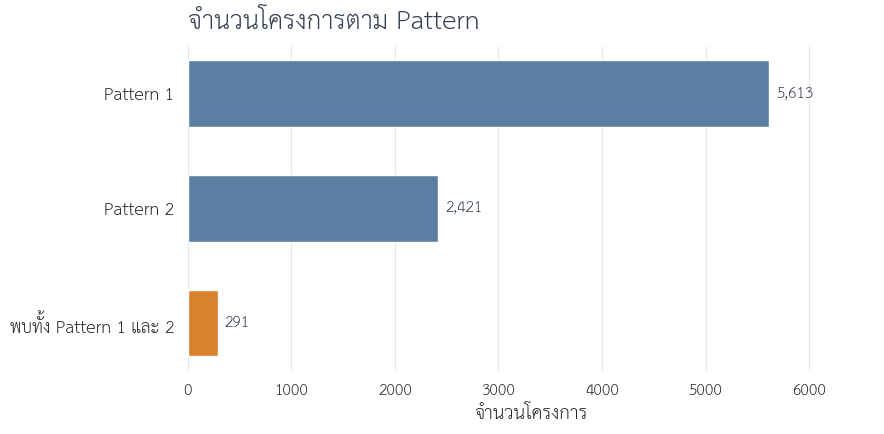

In [16]:
plot_data = pd.Series({
    'Pattern 1': study_review_data['flag_pattern_1'].sum(),
    'Pattern 2': study_review_data['flag_pattern_2'].sum(),
    'พบทั้ง Pattern 1 และ 2': study_review_data['pattern_1_and_2'].sum()
})

fig, ax = plt.subplots(figsize=(9, 4.5))

bars = ax.barh(
    plot_data.index,
    plot_data.values,
    color=[BLUE, BLUE, ORANGE],
    height=0.58
)

ax.bar_label(
    bars,
    labels=[f'{value:,.0f}' for value in plot_data.values],
    padding=5,
    fontsize=11,
    color=TEXT
)

ax.invert_yaxis()
ax.set_xlim(0, plot_data.max() * 1.18)
ax.set_title(
    'จำนวนโครงการตาม Pattern',
    loc='left',
    pad=12,
    color=TEXT
)
ax.set_xlabel('จำนวนโครงการ')
ax.set_ylabel('')

ax.grid(axis='x', color=GRID, linewidth=0.8)
ax.grid(axis='y', visible=False)
ax.set_axisbelow(True)
sns.despine(left=True, bottom=True)

fig.tight_layout()

png_path = figure_dir / 'fig04_01_pattern_overlap.png'
svg_path = figure_dir / 'fig04_01_pattern_overlap.svg'

fig.savefig(png_path, dpi=180, bbox_inches='tight', facecolor='white')
fig.savefig(svg_path, bbox_inches='tight', facecolor='white')

print(f'Saved: {png_path}')
print(f'Saved: {svg_path}')

In [17]:
priority_project_ids = set(
    study_review_data.loc[
        study_review_data['pattern_1_and_2'],
        project_id_column
    ]
)

priority_projects = (
    study_review_data.loc[
        study_review_data[project_id_column].isin(priority_project_ids),
        [
            project_id_column,
            project_name_column,
            agency_column,
            subagency_column,
            province_column,
            method_column,
            budget_column,
            awarded_price_column,
            transaction_date_column,
            'flag_pattern_1',
            'flag_pattern_2',
            'review_priority'
        ]
    ]
    .sort_values(
        [subagency_column, transaction_date_column, budget_column],
        ascending=[True, True, False]
    )
    .reset_index(drop=True)
)

display(priority_projects.head(20))
print(f'โครงการตรวจสอบลำดับแรก: {len(priority_projects):,}')

,รหัสโครงการ,ชื่อโครงการจัดซื้อจัดจ้าง,ชื่อหน่วยงาน,ชื่อหน่วยงานย่อย,จังหวัด,ชื่อวิธีการจัดซื้อจัดจ้าง,วงเงินงบประมาณ (บาท),ราคาที่ตกลงซื้อ / จ้าง ซึ่งรวมทุกสัญญาในโครงการ (บาท),วันที่เกิดรายการ,flag_pattern_1,flag_pattern_2,review_priority
0,68129406554,จ้างขุดเจาะบ่อบาดาลพร้อมก่อสร้างหอถังสูงและติดตั้งถังไฟเบอร์กลาส ขนาดความจุ 6 ลูกบาศก์เมตร และติ...,สำนักงานปลัดกระทรวงทรัพยากรธรรมชาติและสิ่งแวดล้อม,สำนักงานทรัพยากรธรรมชาติและสิ่งแวดล้อมจังหวัด มุกดาหาร,มุกดาหาร,เฉพาะเจาะจง,"498,000.00","489,900.00",29 ธ.ค. 68,True,True,ตรวจสอบลำดับแรก
1,68129405951,จ้างขุดเจาะบ่อบาดาลพร้อมก่อสร้างหอถังสูงและติดตั้งถังไฟเบอร์กลาส ขนาดความจุ 6 ลูกบาศก์เมตร และติ...,สำนักงานปลัดกระทรวงทรัพยากรธรรมชาติและสิ่งแวดล้อม,สำนักงานทรัพยากรธรรมชาติและสิ่งแวดล้อมจังหวัด มุกดาหาร,มุกดาหาร,เฉพาะเจาะจง,"498,000.00","489,900.00",29 ธ.ค. 68,True,True,ตรวจสอบลำดับแรก
2,68129403225,จ้างขุดเจาะบ่อบาดาลพร้อมก่อสร้างหอถังสูงและติดตั้งถังไฟเบอร์กลาส ขนาดความจุ 6 ลูกบาศก์เมตร และติ...,สำนักงานปลัดกระทรวงทรัพยากรธรรมชาติและสิ่งแวดล้อม,สำนักงานทรัพยากรธรรมชาติและสิ่งแวดล้อมจังหวัด มุกดาหาร,มุกดาหาร,เฉพาะเจาะจง,"498,000.00","489,900.00",29 ธ.ค. 68,True,True,ตรวจสอบลำดับแรก
3,68129401438,จ้างขุดเจาะบ่อบาดาลพร้อมก่อสร้างหอถังสูงและติดตั้งถังไฟเบอร์กลาส ขนาดความจุ 6 ลูกบาศก์เมตร และติ...,สำนักงานปลัดกระทรวงทรัพยากรธรรมชาติและสิ่งแวดล้อม,สำนักงานทรัพยากรธรรมชาติและสิ่งแวดล้อมจังหวัด มุกดาหาร,มุกดาหาร,เฉพาะเจาะจง,"498,000.00","489,900.00",29 ธ.ค. 68,True,True,ตรวจสอบลำดับแรก
4,68129406134,จ้างขุดเจาะบ่อบาดาลพร้อมก่อสร้างหอถังสูงและติดตั้งถังไฟเบอร์กลาส ขนาดความจุ 6 ลูกบาศก์เมตร และติ...,สำนักงานปลัดกระทรวงทรัพยากรธรรมชาติและสิ่งแวดล้อม,สำนักงานทรัพยากรธรรมชาติและสิ่งแวดล้อมจังหวัด มุกดาหาร,มุกดาหาร,เฉพาะเจาะจง,"498,000.00","489,900.00",29 ธ.ค. 68,True,True,ตรวจสอบลำดับแรก
5,68129406360,จ้างขุดเจาะบ่อบาดาลพร้อมก่อสร้างหอถังสูงและติดตั้งถังไฟเบอร์กลาส ขนาดความจุ 6 ลูกบาศก์เมตร และติ...,สำนักงานปลัดกระทรวงทรัพยากรธรรมชาติและสิ่งแวดล้อม,สำนักงานทรัพยากรธรรมชาติและสิ่งแวดล้อมจังหวัด มุกดาหาร,มุกดาหาร,เฉพาะเจาะจง,"498,000.00","489,900.00",29 ธ.ค. 68,True,True,ตรวจสอบลำดับแรก
6,68129401561,จ้างขุดเจาะบ่อบาดาลพร้อมก่อสร้างหอถังสูงและติดตั้งถังไฟเบอร์กลาส ขนาดความจุ 6 ลูกบาศก์เมตร และติ...,สำนักงานปลัดกระทรวงทรัพยากรธรรมชาติและสิ่งแวดล้อม,สำนักงานทรัพยากรธรรมชาติและสิ่งแวดล้อมจังหวัด มุกดาหาร,มุกดาหาร,เฉพาะเจาะจง,"498,000.00","489,900.00",29 ธ.ค. 68,True,True,ตรวจสอบลำดับแรก
7,68129401949,จ้างขุดเจาะบ่อบาดาลพร้อมก่อสร้างหอถังสูงและติดตั้งถังไฟเบอร์กลาส ขนาดความจุ 6 ลูกบาศก์เมตร และติ...,สำนักงานปลัดกระทรวงทรัพยากรธรรมชาติและสิ่งแวดล้อม,สำนักงานทรัพยากรธรรมชาติและสิ่งแวดล้อมจังหวัด มุกดาหาร,มุกดาหาร,เฉพาะเจาะจง,"498,000.00","489,900.00",29 ธ.ค. 68,True,True,ตรวจสอบลำดับแรก
8,68129400699,จ้างขุดเจาะบ่อบาดาลพร้อมก่อสร้างหอถังสูงและติดตั้งถังไฟเบอร์กลาส ขนาดความจุ 6 ลูกบาศก์เมตร และต...,สำนักงานปลัดกระทรวงทรัพยากรธรรมชาติและสิ่งแวดล้อม,สำนักงานทรัพยากรธรรมชาติและสิ่งแวดล้อมจังหวัด มุกดาหาร,มุกดาหาร,เฉพาะเจาะจง,"498,000.00","489,900.00",29 ธ.ค. 68,True,True,ตรวจสอบลำดับแรก
9,68129401353,จ้างขุดเจาะบ่อบาดาลพร้อมก่อสร้างหอถังสูงและติดตั้งถังไฟเบอร์กลาส ขนาดความจุ 6 ลูกบาศก์เมตร และติ...,สำนักงานปลัดกระทรวงทรัพยากรธรรมชาติและสิ่งแวดล้อม,สำนักงานทรัพยากรธรรมชาติและสิ่งแวดล้อมจังหวัด มุกดาหาร,มุกดาหาร,เฉพาะเจาะจง,"498,000.00","489,900.00",29 ธ.ค. 68,True,True,ตรวจสอบลำดับแรก


โครงการตรวจสอบลำดับแรก: 291


### ผลการซ้อนทับ

โครงการที่พบทั้ง Pattern 1 และ Pattern 2 เป็นกลุ่มตรวจสอบลำดับแรก

## 6. สรุป

- Pattern 1 พบ 1,245 กลุ่ม รวม 5,623 โครงการ
- Pattern 2 พบ 142 คู่หน่วยงานย่อย–ผู้รับจ้าง รวม 2,421 โครงการ
- Pattern 3 ไม่พบคู่จังหวัด–ผู้รับจ้างที่ผ่านเกณฑ์ส่วนแบ่งขั้นต่ำ 50%
- กลุ่มตรวจสอบลำดับแรกคือโครงการที่พบทั้ง Pattern 1 และ Pattern 2
- ผลลัพธ์เป็นสัญญาณสำหรับเปิดเอกสารตรวจสอบเพิ่มเติม

## 7. บันทึกผลลัพธ์

In [18]:
project_flags = project_data[
    [
        project_id_column,
        'in_study_scope',
        'flag_pattern_1',
        'flag_pattern_2'
    ]
].copy()

project_flags = project_flags.merge(
    study_review_data[
        [project_id_column, 'review_priority']
    ],
    on=project_id_column,
    how='left',
    validate='one_to_one'
)

output_objects = {
    'project_review_indicators_2569.csv': project_flags,
    'priority_review_projects_2569.csv': priority_projects,
    'repeated_near_500k_clusters_2569.csv': repeated_clusters,
    'high_supplier_dependence_2569.csv': high_dependence_relationships,
    'near_500k_sensitivity_2569.csv': near_ceiling_sensitivity,
    'cluster_size_sensitivity_2569.csv': cluster_size_sensitivity,
    'supplier_dependence_sensitivity_2569.csv': supplier_dependence_sensitivity,
    'province_supplier_summary_2569.csv': province_supplier_relationships,
    'geographic_supplier_dominance_sensitivity_2569.csv': geographic_sensitivity
}

export_records = []

for file_name, output_data in output_objects.items():
    output_path = processed_dir / file_name
    output_data.to_csv(
        output_path,
        index=False,
        encoding='utf-8-sig'
    )
    export_records.append({
        'file_name': file_name,
        'rows': len(output_data),
        'file_size_mb': output_path.stat().st_size / 1024**2
    })

export_summary = pd.DataFrame(export_records)
display(export_summary)

,file_name,rows,file_size_mb
0,project_review_indicators_2569.csv,178978,8.19
1,priority_review_projects_2569.csv,291,0.23
2,repeated_near_500k_clusters_2569.csv,1244,0.26
3,high_supplier_dependence_2569.csv,142,0.03
4,near_500k_sensitivity_2569.csv,4,0.00
5,cluster_size_sensitivity_2569.csv,4,0.00
6,supplier_dependence_sensitivity_2569.csv,9,0.00
7,province_supplier_summary_2569.csv,32221,5.62
8,geographic_supplier_dominance_sensitivity_2569.csv,27,0.00
